<a href="https://colab.research.google.com/github/alxagathangel/FRTN65-Lab1/blob/main/FRTN65_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**[FRTN65] Lab 1**
```
Alexandros Antonis Agathangelidis
MSSR - 1751
```
### **Music Taste Prediction**

> The code for this assignment is built using the example `lab_song_classification.ipynb` as a base with the help of [sci-kit documentation](https://scikit-learn.org/stable/user_guide.html) to implement a number of the suggested methods.



Methods used:
1. k-Nearest Neighbor
2. Logistic Regression
3. Random Forest
4. Support Vector Machine


In [ ]:
#---MODULES---#
# general tools
import numpy as np
import pandas as pd
# plotting
import matplotlib.pyplot as plt
import seaborn as sns
# pre-processing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif, SelectFromModel
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
# methods
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
# evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
#---DATASETS---#
!wget -O training_data.csv http://handsonml.control.lth.se/data/training_data.csv
!wget -O songs_to_classify.csv http://handsonml.control.lth.se/data/songs_to_classify.csv

--2026-09-29 14:27:18--  http://handsonml.control.lth.se/data/training_data.csv
Resolving handsonml.control.lth.se (handsonml.control.lth.se)... 130.235.83.36, 2001:6b0:16:248:2406:1311:4200:0
Connecting to handsonml.control.lth.se (handsonml.control.lth.se)|130.235.83.36|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 54950 (54K) [text/csv]
Saving to: ‘training_data.csv’

training_data.csv   100%[===================>]  53.66K  --.-KB/s    in 0.06s   

2026-09-29 14:27:18 (943 KB/s) - ‘training_data.csv’ saved [54950/54950]

--2026-09-29 14:27:18--  http://handsonml.control.lth.se/data/songs_to_classify.csv
Resolving handsonml.control.lth.se (handsonml.control.lth.se)... 130.235.83.36, 2001:6b0:16:248:2406:1311:4200:0
Connecting to handsonml.control.lth.se (handsonml.control.lth.se)|130.235.83.36|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14306 (14K) [text/csv]
Saving to: ‘songs_to_classify.csv’

songs_to_classify.c 100%[==========

In [ ]:
# Load data
train = pd.read_csv("training_data.csv")
test = pd.read_csv("songs_to_classify.csv") # only used for final prediction
train.shape, test.shape

# Set Features (every column except label)
features = [col for col in train.columns if col != 'label']

# **Pre-Processing**

## Inspecting Data
There are 13 features in the set, which can be separated into three distinct types:
* **Numerical** `(int || float)`
    * duration_ms, loudness, tempo
* **Scale** [0.0 - 1.0] `(float)`
    * acousticness, dancability, energy, instrumentalness, liveness, speechiness, valence
* **Categorical** `(int || string)`
    * key, mode, time_signature

The features `key`, `mode`, and `time_signature` should be considered qualitative, while the rest quantitive. The reason for this is because these three features don't have a numeric representation and instead represent characteristics. Because treating them as numerical values would create issues with classification, they will be one-hot encoded.

In [ ]:
train.sample(10)

,acousticness,danceability,duration,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,label
25,0.9940,0.450,199493,0.0153,0.919000,2,0.0630,-25.257,1,0.0552,81.327,4,0.226,1
332,0.2060,0.797,244240,0.6540,0.002140,9,0.0641,-12.652,1,0.0389,134.055,4,0.963,1
695,0.0435,0.652,220571,0.7500,0.000000,10,0.1880,-5.589,1,0.0339,94.515,4,0.465,1
71,0.0091,0.405,220333,0.7600,0.000000,7,0.3750,-4.863,1,0.0407,109.875,4,0.317,1
304,0.9580,0.304,154600,0.1390,0.468000,0,0.0920,-18.236,0,0.0327,84.272,4,0.271,1
518,0.7530,0.604,223280,0.4570,0.000000,5,0.1240,-6.942,0,0.0304,136.968,4,0.306,1
634,0.3250,0.467,243720,0.6780,0.000023,4,0.1010,-6.729,0,0.0397,149.220,3,0.156,1
266,0.8920,0.187,294827,0.3510,0.000003,10,0.6730,-9.935,1,0.0323,84.310,3,0.141,1
242,0.4780,0.652,237013,0.3970,0.000946,7,0.0679,-15.245,1,0.0385,82.235,4,0.858,1
744,0.1240,0.519,242227,0.4950,0.006260,6,0.1830,-11.002,0,0.1010,95.078,4,0.262,1


In [ ]:
numeric_features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'duration'
]
categorical_features = ['key', 'mode', 'time_signature']

train[numeric_features].describe()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration
count,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000
mean,0.357394,0.596439,0.594188,0.100245,0.203376,-8.509339,0.098966,120.405761,0.497321,220112.733333
std,0.338405,0.172036,0.253301,0.259921,0.177609,5.039488,0.104715,28.378116,0.239615,65587.690483
min,0.000001,0.107000,0.009250,0.000000,0.024000,-29.601000,0.023400,55.747000,0.033200,33840.000000
25%,0.037150,0.480000,0.423250,0.000000,0.094550,-10.173500,0.035900,98.998000,0.297000,185490.250000
50%,0.244500,0.606000,0.631500,0.000010,0.129000,-7.270000,0.048750,120.104500,0.483000,215108.500000
75%,0.678500,0.715750,0.804750,0.002245,0.264750,-5.097750,0.113000,138.074750,0.684500,244236.750000
max,0.994000,0.986000,0.995000,0.967000,0.979000,-0.533000,0.721000,204.162000,0.975000,675360.000000


## Plotting Data
Visualizing the data will help in better understanding the features and any possible relations to each other.


### Correlation Map
The heatmap can help determine potential relationships between the features. Values closer to `1.0` signify a stronger correlation.

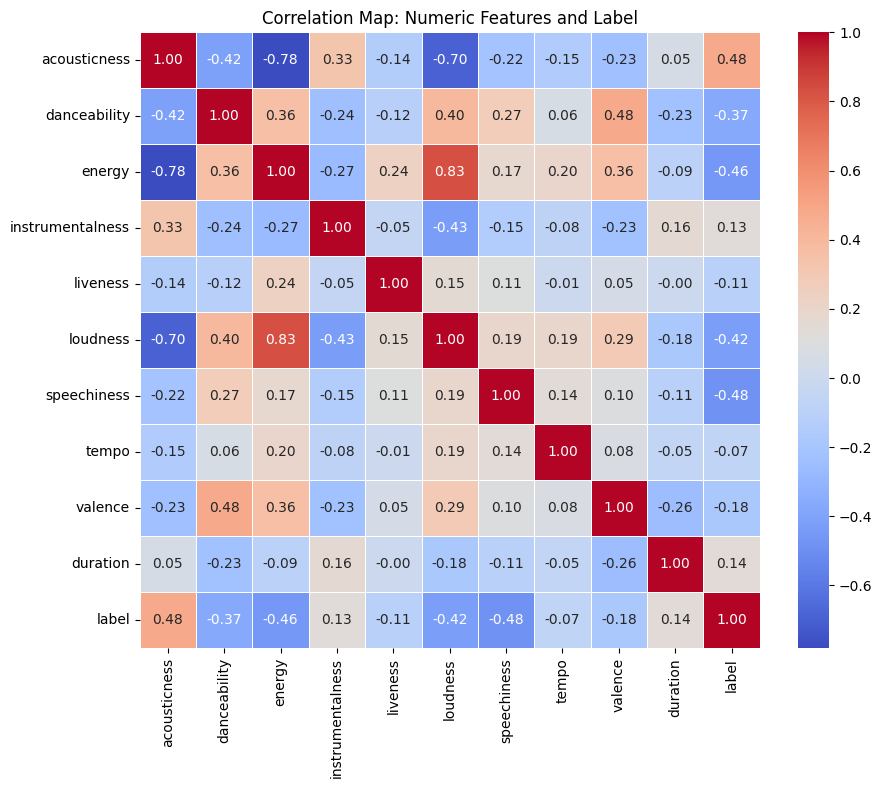

In [ ]:
numeric_corr = train[numeric_features + ['label']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    numeric_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Map: Numeric Features and Label")
plt.show()

Some expected conclusions can be drawn here.
* The highest correlation is between energy and loudness.
* Other high correlation (colored orange on the map) values include:
    * valence & danceability
    * loudness & danceability
    * energy & valence
    * energy & dancability
    * instrumentalness & acousticness
* There is a very high correlation between acousticness and the true label.

From a musical perspective, it is logical for these features to be closeley connected, so it is good to verify this visually.

### Scatter Matrix
While a bit difficult to see, the scatter matrix can demonstrate the relationships between the features in a more visual way compared to the correlation map.

The diagonal also indicates the distribution of each feature.

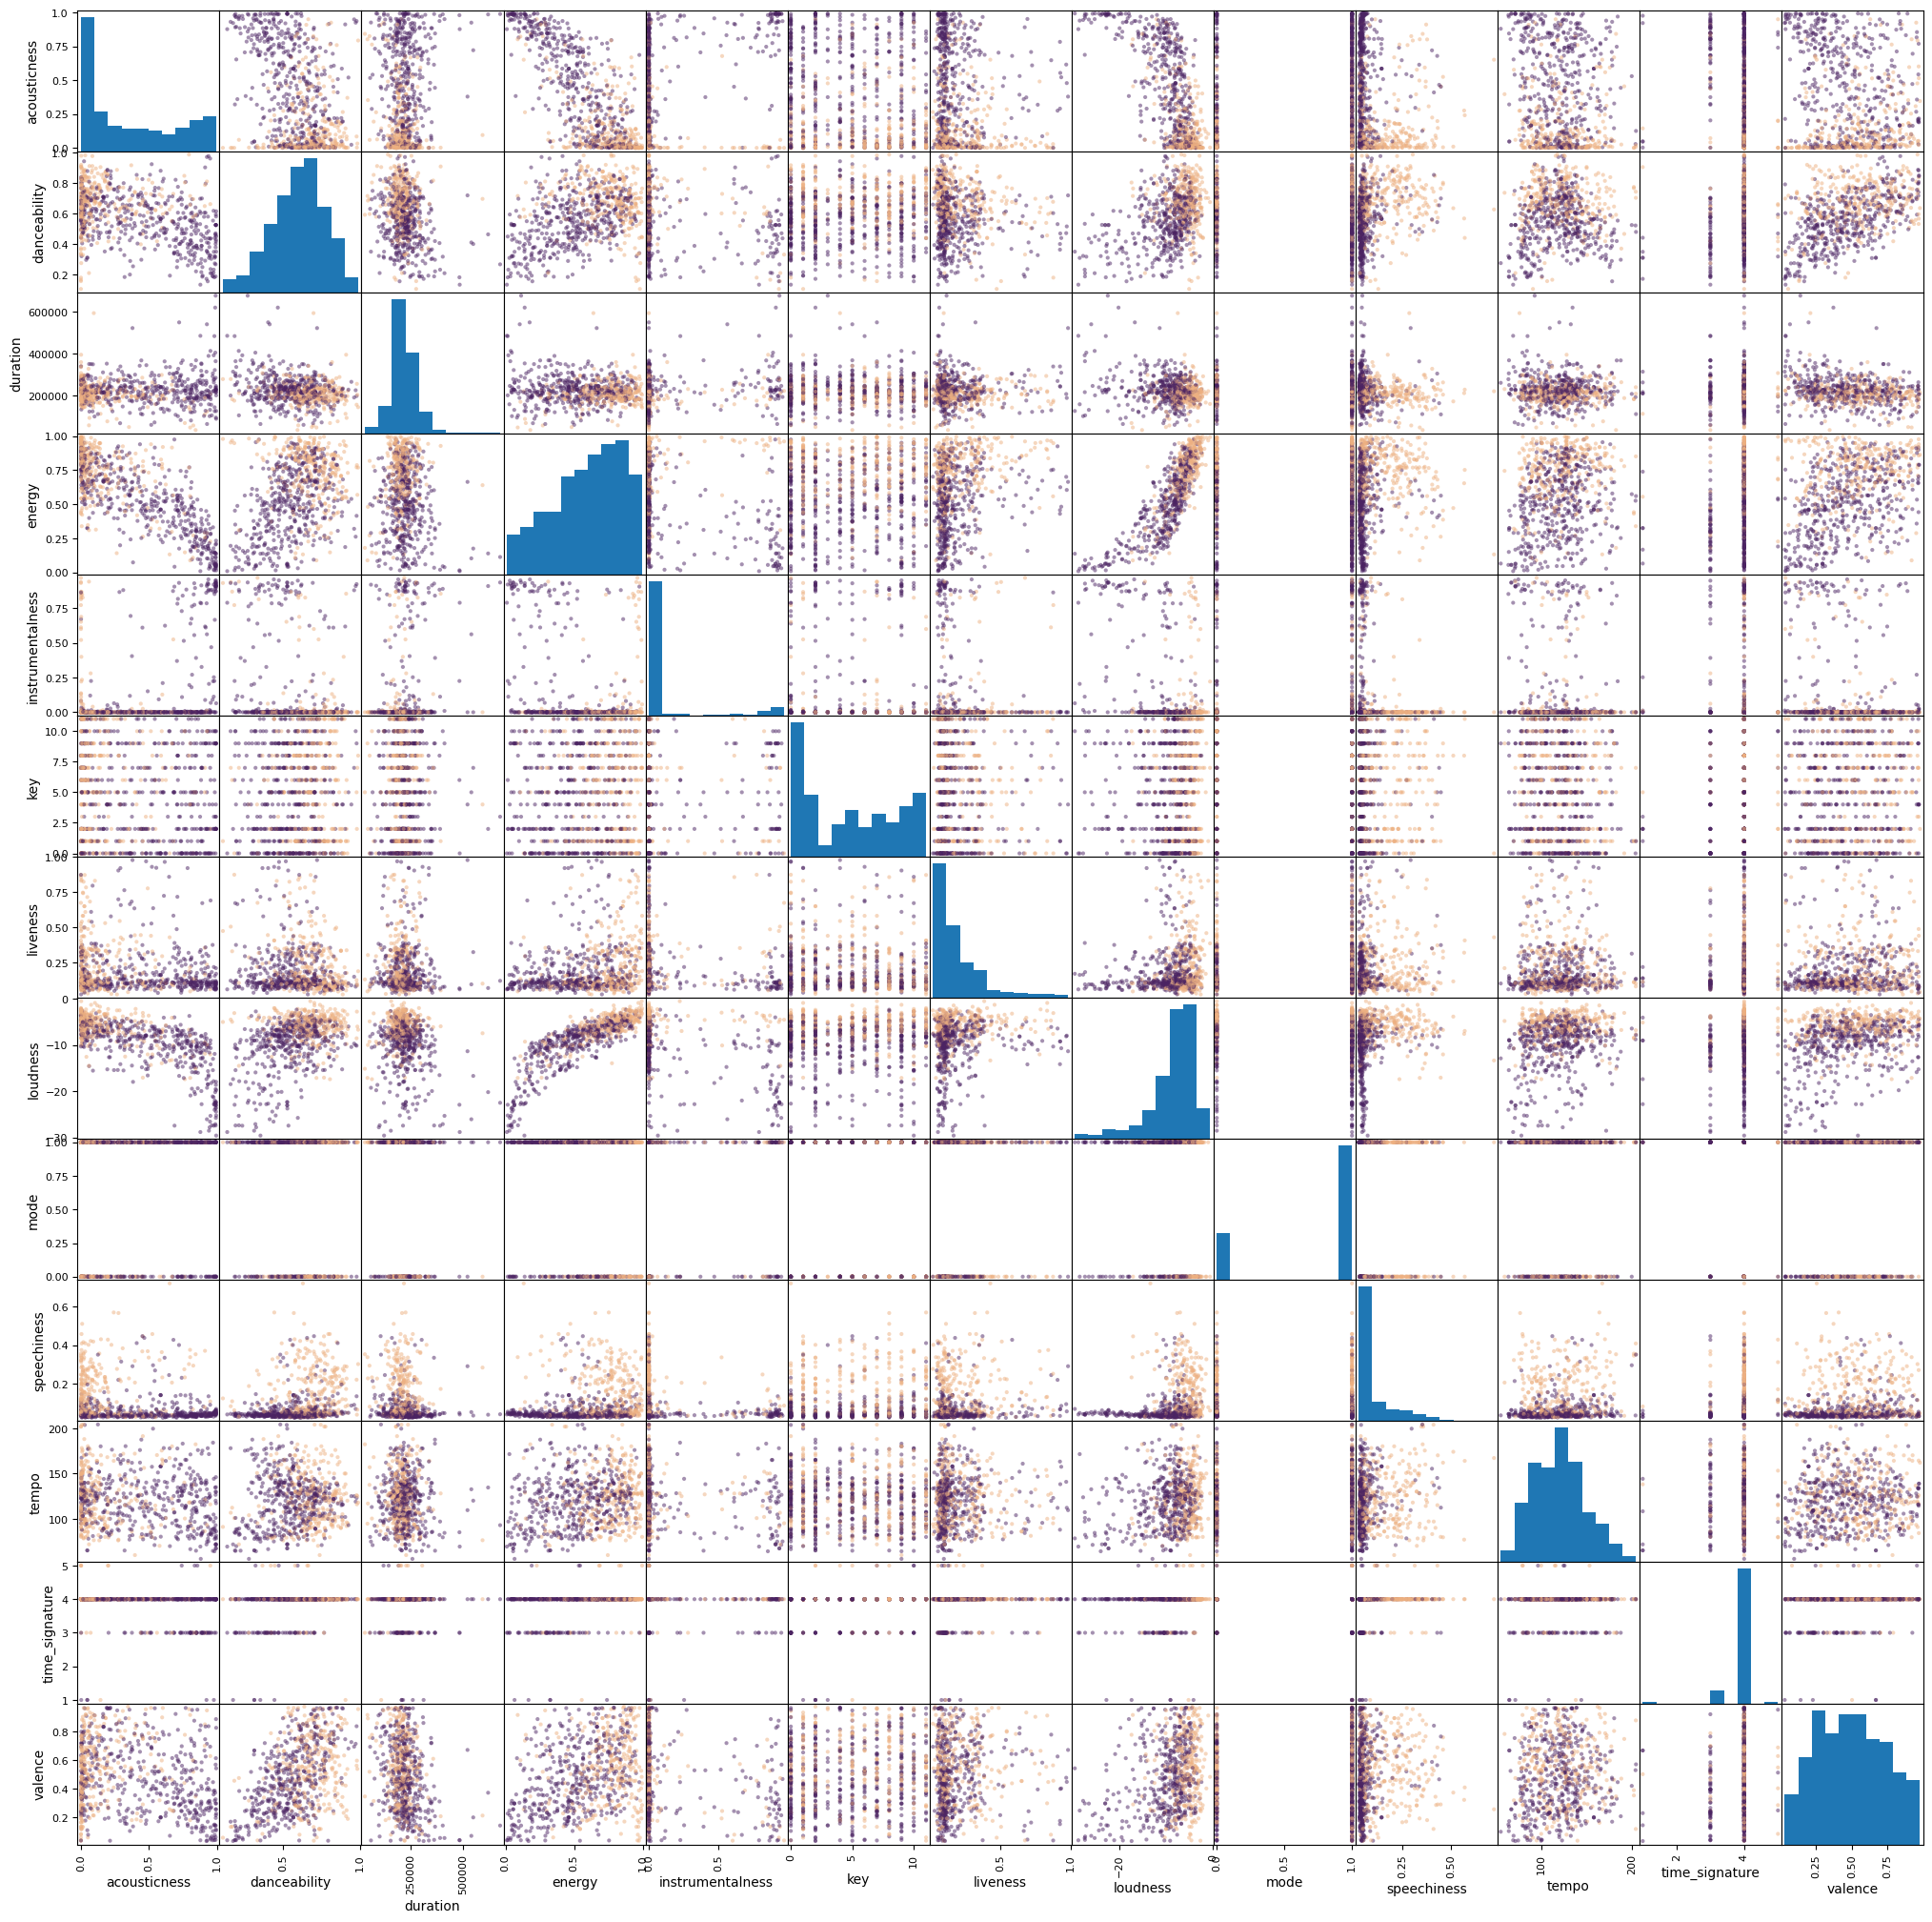

In [ ]:
scatter_matrix = pd.plotting.scatter_matrix(train[features], figsize=(25,25), c=train['label'], cmap='flare')
plt.show()

Most of the features are very clustered, making a linear separation difficult. There are, however, some combinations of features (such as instrumentalness & energy, speechiness & duration, or speechiness & duration) that can be separated in a satisfactory manner.

On the other hand, most of the features are split in a way that would make k-Neighbor classification very efficient.

Some useful measurements to determine feature selection can be extracted from `SelectKBest()` using the mutual information score as a metric for the selection or `SelectFromModel()` which fits estimators based on the mean (for the `LogicRegression()` model) and median (for `RandomForestClassifier()`) threshold.

### Split into Training/Validation
Before splitting the train set into training and validation, the data points should be shuffled randomly, in the case they're organized in a certain way that will diminish estimator quality.
In order to achieve this, the argument `shuffle` is set to `True` on the `train_test_split()` method. The proportion of true/false classifications between the split is preserved with `stratify=y`.

In addition, the validation size will be 20% of the total training data, which is defined in the argument `test_size=0.2`, and will not be used for cross-validation or parameter tuning. This ratio is common practice among machine learning impelementations with the amount of data given. There is no reason to pick a lower validation percentage, since data is not scarce.

In [ ]:
X = train[features].copy()
y = train['label'].copy()

X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.20,shuffle=True,stratify=y,random_state=42)

X_test = test[features].copy()

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True))

print("\nValidation class proportions:")
print(y_val.value_counts(normalize=True))

Training set: (600, 13)
Validation set: (150, 13)
Test set: (200, 13)

Training class proportions:
label
1    0.603333
0    0.396667
Name: proportion, dtype: float64

Validation class proportions:
label
1    0.6
0    0.4
Name: proportion, dtype: float64


## Creating Pipelines
To avoid data from validation leaking into the training set, pipelines will be utilized. The objects created with Pipeline behave the same as the estimators, so `fit` and `predict` methods can be used normally.

*It is important that this step is executed AFTER the training/validation split.* Once data is split, a pipeline is created for every method and included in the beginning of every implementation as `[method]_pipe`.

Each model will have its own pipeline, including:
1. Preprocessing, which includes
    * appropriate scaling of numerical values
    * one-hot encoding of categorical values
3. Feature selection
4. Implemented ML method

# **Methods**

## Logistic Regression
Scaling is performed before L1-based feature selection since L1 is sensitive to feature scaling. `StandardScaler()` is used to standardize numerical features with mean 0 and variance 1.

For categorical features, `OneHotEncoder()` ignores any potential unknown categories by setting the argument `'handle_unknown'='ignore'`, and ensures the output is a dense array with `'sparse_output'=False`. This is good practice when the dataset is small, and ensures it can be processed by methods that can't handle sparsity [(1)](https://medium.com/@oluwasayofarotimi/understanding-one-hot-encoding-sparse-matrices-in-statistical-modeling-and-machine-learning-33f18107e280).

Cross validation is done with `StratifiedKFold()` which ensures that each fold has approximately the same percentage of samples of each target class.

`GridSearchCV()` is used to tune the regularizations and penalties, searching over all specified parameters (denoted as comments in the code) to find the best combination for the estimator based on a specific scoring metric (F1 in this case).

The parameters tuned are the regularization strengths `'select__estimator__C'` and `'model__C'` for the feature selection and the model itself, which span across a range of [0.001-100] on the logarithmic scale in order to find the balance between optimal fitting and underfitting. The regularization penalty `'model__penalty'` tests both L1 and L2 regularization to determine the best outcome.

By setting `n_jobs=-1`, the program can use all the CPU cores in order to increase execution speed.
Upon finding the best combination of parameters, the model is refit.

**All methods will use the same format, any aspects that differ will be explained.*

In [ ]:
preprocessor_log = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)])

log_pipe = Pipeline([
    ('preprocess', preprocessor_log),
    # features selected with LogisticRegression estimator with
    # L1 penalty based on coefficients > mean threshold
    ('select', SelectFromModel(
        LogisticRegression(
            penalty='l1',
            solver='liblinear',
            random_state=42,
            max_iter=2000),
        threshold='mean')),
    ('model', LogisticRegression(
        solver='liblinear',
        random_state=42,
        max_iter=2000))])

# hyperparameters to tune
log_param_grid = {
    'select__estimator__C': np.logspace(-3, 2, 6), # regularization strength for LR in feature selection
    'model__C': np.logspace(-3, 2, 6), # regularization strength for main LR model
    'model__penalty': ['l1', 'l2'] # L1 or L2 penalty
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_search = GridSearchCV(
    estimator=log_pipe,
    param_grid=log_param_grid, # search through grid
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1, # parallel processing
    refit=True # refit best estimator
)

log_search.fit(X_train, y_train)

print("--- LOGISTIC REGRESSION ---")
print("Best parameters:", log_search.best_params_)
print(f"Best CV Macro F1: {log_search.best_score_:.3f}")

log_val_pred = log_search.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, log_val_pred):.3f}")
print(f"Validation Precision: {precision_score(y_val, log_val_pred, average='macro'):.3f}")
print(f"Validation Recall: {recall_score(y_val, log_val_pred, average='macro'):.3f}")
print(f"Validation F1: {f1_score(y_val, log_val_pred, average='macro'):.3f}")

--- LOGISTIC REGRESSION ---
Best parameters: {'model__C': np.float64(0.1), 'model__penalty': 'l1', 'select__estimator__C': np.float64(0.001)}
Best CV Macro F1: 0.805
Validation Accuracy: 0.807
Validation Precision: 0.801
Validation Recall: 0.792
Validation F1: 0.796


## k-Nearest Neighbors
Since kNN is very scale sensitive, considering it's a distance based algorithm. `MinMaxScaler()` is applied to numerical values to scale the features between 0 and 1, and `OneHotEncoder()` to categorical features using the same practice as Logistic Regression.

Feature selection is done based on the mutual info score function to measure dependency between features in an efficient way [(2)](https://www.kaggle.com/discussions/getting-started/563669). The argument `k='all'` keeps all features initially so they can be tuned during grid search.

The parameters set for the grid search are denoted as comments. A range of parameters is proposed to ensure the best combination is found. For `select__k`, a range of values is suggested, ranging from some to all the features (not all features should be used but there should also be a reasonable amount of features, so 5 is the lowest suggested value). The neighbor selection `model__n_neighbors` tests between various values, recognizing that less neighbors make the model more noise sensitive, while more neighbors can possibly lead to overfitting. The values 3 or 25 are certainly bad fits, but worth keeping for comparison's sake. For the weight function, `model__weights` chooses between equal weight values across the neighbors, or a distance-based weighting system where more weight is applied to closer neighbors. The power parameter `model__p` tests between L1 and L2 norm to find which distance (Manhattan or Euclidean) captures similarity the best.

In [ ]:
preprocessor_knn = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features), # scale features between 0 and 1
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)])

knn_pipe = Pipeline([
    ('preprocess', preprocessor_knn),
    ('select', SelectKBest(score_func=mutual_info_classif, k='all')),
    ('model', KNeighborsClassifier())])

knn_param_grid = {
    'select__k': [5, 8, 10, 'all'], # num of features to selection from SelectKBest
    'model__n_neighbors': [3, 5, 7, 9, 15, 25], # num of neighbors for classfification
    'model__weights': ['uniform', 'distance'], # weight func: equal weight or based on distance
    'model__p': [1, 2] # power parameter (1 for Manhattan, 2 for Euclidean distance)
}

knn_search = GridSearchCV(
    estimator=knn_pipe,
    param_grid=knn_param_grid,
    scoring='f1_macro',
    cv=cv, # earlier splitting strategy
    n_jobs=-1,
    refit=True
)

knn_search.fit(X_train, y_train)

print("--- k-NEAREST NEIGHBORS ---")
print("Best parameters:", knn_search.best_params_)
print(f"Best CV Macro F1: {knn_search.best_score_:.3f}")

knn_val_pred = knn_search.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, knn_val_pred):.3f}")
print(f"Validation Precision: {precision_score(y_val, knn_val_pred, average='macro'):.3f}")
print(f"Validation Recall: {recall_score(y_val, knn_val_pred, average='macro'):.3f}")
print(f"Validation F1: {f1_score(y_val, knn_val_pred, average='macro'):.3f}")

--- k-NEAREST NEIGHBORS ---
Best parameters: {'model__n_neighbors': 7, 'model__p': 1, 'model__weights': 'distance', 'select__k': 5}
Best CV Macro F1: 0.834
Validation Accuracy: 0.813
Validation Precision: 0.819
Validation Recall: 0.789
Validation F1: 0.797


## Random Forest Classifier
Since Random Forests concern relative order between feature values, scaling isn't needed, so this part is skipped in the pre-processing of numerical values. Categorical features are still one-hot encoded in the same way as the previous estimators.

`RandomForestClassifier` is used to determine feature importance and selects fearures based on the median threshold in accordance to Random Forest methods. Parameter tuning is done using CV. The grid search parameters are specified in the code's comments.

The number of decision trees is set to `n_estimators=300` to ensure the robustness of the model, all while considering the trade-off between performance and computational time.

For parameter tuning, `'select__estimator__max_depth'` will determine the maximum tree depth for feature selection. `None` will set no limit to the tree depth, which is less optimal when considering overfitting. `'model__n_estimators'` sets the number of trees, where 200 and 500 can be a good trade-off in respect to the 300 trees in feature selection. In general, more trees will lead to a more robust model at the cost of higher computational time. For the model, `'model__max_depth'` takes similar values as the estimator, the minimum number of samples for a leaf node `'model__min_samples_leaf'` is set to a range between 1-5 to test whether a higher sample will reasonably lead to better generalization, and `'model__max_features'` will either take the square root of the 2-logarithm of the feature amount to determine how many features should be considered.

In [ ]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)])

tree_pipe = Pipeline([
    ('preprocess', preprocessor_tree),
    ('select', SelectFromModel(
        RandomForestClassifier(
            n_estimators=300, # tree num
            random_state=42,
            n_jobs=-1),
        threshold='median')),
    ('model', RandomForestClassifier(random_state=42,n_jobs=-1))])

tree_param_grid = {
    'select__estimator__max_depth': [None, 5, 10], # max tree depth for feature selection
    'model__n_estimators': [200, 500], # tree num in main model
    'model__max_depth': [None, 5, 10, 15], # max tree depth for main model
    'model__min_samples_leaf': [1, 2, 5], # min sample num to be at leaf node
    'model__max_features': ['sqrt', 'log2'] # num of features to consider
}

tree_search = GridSearchCV(
    estimator=tree_pipe,
    param_grid=tree_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    refit=True
)

tree_search.fit(X_train, y_train)

print("--- RANDOM FOREST ---")
print("Best parameters:", tree_search.best_params_)
print(f"Best CV Macro F1: {tree_search.best_score_:.3f}")

tree_val_pred = tree_search.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, tree_val_pred):.3f}")
print(f"Validation Precision: {precision_score(y_val, tree_val_pred, average='macro'):.3f}")
print(f"Validation Recall: {recall_score(y_val, tree_val_pred, average='macro'):.3f}")
print(f"Validation F1: {f1_score(y_val, tree_val_pred, average='macro'):.3f}")

--- RANDOM FOREST ---
Best parameters: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 200, 'select__estimator__max_depth': 10}
Best CV Macro F1: 0.831
Validation Accuracy: 0.807
Validation Precision: 0.800
Validation Recall: 0.794
Validation F1: 0.797


## Support Vector Machine
Since SVM is distance-based, it's sensitive to feature scale, so numerical features are standardized. Similar to the previous methods, categorical variables are one-hot encoded. Feature selection is kept inside the pipeline so it is fitted independently inside each CV training fold.

Feature selection is done similarly to k-NN to ensure proper handling of non-linear relations between features. The model uses RBF kernel, which is best used when handling complex, non-linear data [(3)](https://www.geeksforgeeks.org/machine-learning/radial-basis-function-kernel-machine-learning/), and the probability estimates are not calculated in order to decrease training time.

For the parameters, choosing between a number of features `select__k` is needed since feature selection leaves it up to parameter tuning similar to k-NN. The top features are investigated in a range from 5-10, with all being a non-optimal choice but still worth checking. `model__C` will tune the regularization parameter, where small values will lead to more misclassifications due to the strong regularization, while larger values with weaker regularization will have fewer misclassifications because of the narrow margins. Lower values of the kernel coefficient `model__gamma` will lead to a large influence of a single train sample, while higher values indicate lower influence. Some standard values to consider are scale and auto, but 0.01 and 0.1 are also used for finetuning.

In [ ]:
preprocessor_svm = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=False), categorical_features)])


svm_pipe = Pipeline([
    ('preprocess', preprocessor_svm),
    ('select', SelectKBest(score_func=mutual_info_classif,k='all')),
    ('model', SVC(kernel='rbf',probability=False,random_state=42)) # radial basis function kernel used, probability not computed
])

svm_param_grid = {
    'select__k': [5, 8, 10, 'all'], # num of top features from SelectKBest
    'model__C': [0.1,1,10,100], # classification error parameter
    'model__gamma': ['scale','auto',0.01,0.1] # kernel coef to control individual training sample influence
}

svm_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    refit=True
)

svm_search.fit(X_train, y_train)

print("--- SUPPORT VECTOR MACHINE ---")
print("Best parameters:", svm_search.best_params_)
print(f"Best CV Macro F1: {svm_search.best_score_:.3f}")

svm_val_pred = svm_search.predict(X_val)

print(f"Validation Accuracy: {accuracy_score(y_val, svm_val_pred):.3f}")
print(f"Validation Precision (macro): {precision_score(y_val, svm_val_pred, average='macro'):.3f}")
print(f"Validation Recall (macro): {recall_score(y_val, svm_val_pred, average='macro'):.3f}")
print(f"Validation F1 (macro): {f1_score(y_val, svm_val_pred, average='macro'):.3f}")

--- SUPPORT VECTOR MACHINE ---
Best parameters: {'model__C': 10, 'model__gamma': 'scale', 'select__k': 5}
Best CV Macro F1: 0.839
Validation Accuracy: 0.807
Validation Precision (macro): 0.813
Validation Recall (macro): 0.781
Validation F1 (macro): 0.789


# **Evaluation**
Model evaluation is done using F1 macro score. This is done to ensure unweighted score contribution between the two classes [(4)](https://www.splunk.com/en_us/blog/learn/f1-score.html), leading to a fair comparison between the models. The plot shows the validation accuracy, precision and recall of the four models, as well as the final evaluator F1.

,Model,CV Macro F1,Validation Accuracy,Validation Precision (macro),Validation Recall (macro),Validation F1 (macro)
0,Logistic Regression,0.805,0.807,0.801,0.792,0.796
1,k-Nearest Neighbors,0.834,0.813,0.819,0.789,0.797
2,Random Forest,0.831,0.807,0.800,0.794,0.797
3,Support Vector Machine,0.839,0.807,0.813,0.781,0.789


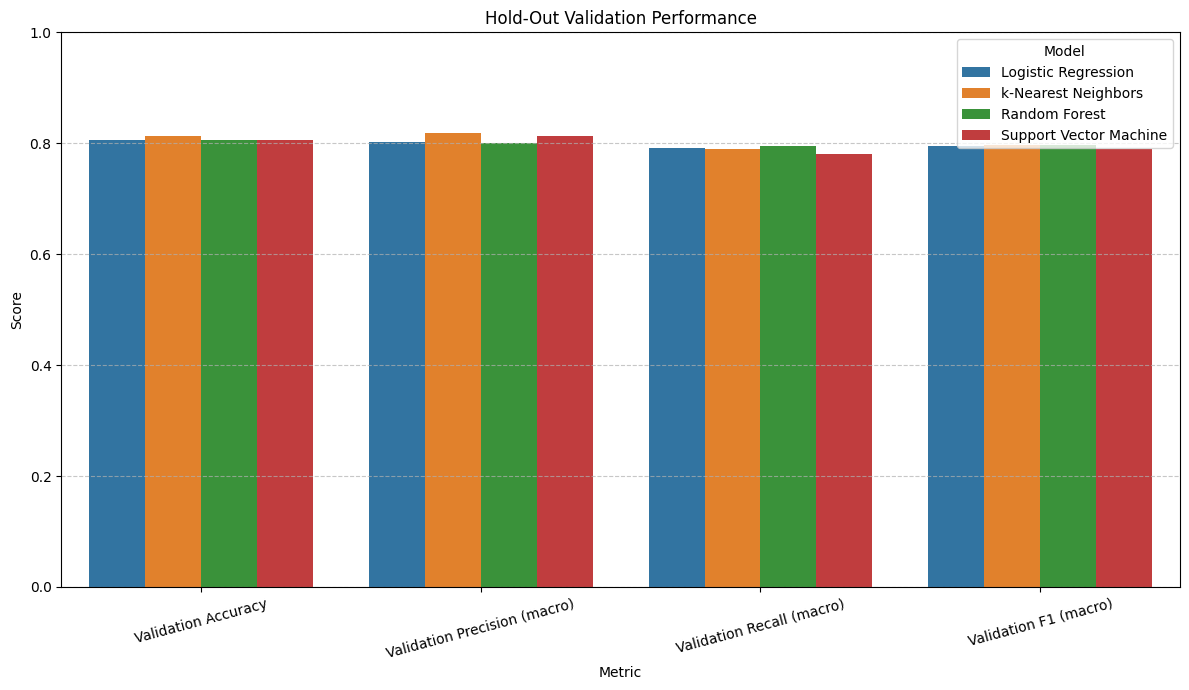

Selected production model based on validation Macro F1: k-Nearest Neighbors


In [ ]:
models = ['Logistic Regression', 'k-Nearest Neighbors', 'Random Forest', 'Support Vector Machine']
searches = [log_search, knn_search, tree_search, svm_search]
validation_predictions = [log_val_pred, knn_val_pred, tree_val_pred, svm_val_pred]

rows = []

for model_name, search, pred in zip(models, searches, validation_predictions):
    rows.append({
        'Model': model_name,
        'CV Macro F1': search.best_score_,
        'Validation Accuracy': accuracy_score(y_val, pred),
        'Validation Precision (macro)': precision_score(y_val, pred, average='macro'),
        'Validation Recall (macro)': recall_score(y_val, pred, average='macro'),
        'Validation F1 (macro)': f1_score(y_val, pred, average='macro')
    })

results_df = pd.DataFrame(rows)
display(results_df.round(3))

plot_df = results_df.melt(
    id_vars='Model',
    value_vars=[
        'Validation Accuracy',
        'Validation Precision (macro)',
        'Validation Recall (macro)',
        'Validation F1 (macro)'
    ],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=plot_df)
plt.title('Hold-Out Validation Performance')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# select in-production model using F1
best_idx = results_df['Validation F1 (macro)'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']

search_map = {
    'Logistic Regression': log_search,
    'k-Nearest Neighbors': knn_search,
    'Random Forest': tree_search,
    'Support Vector Machine': svm_search
}

best_search = search_map[best_model_name]

print(f"Selected production model based on validation Macro F1: {best_model_name}")

## In-Production Deployment
The best model is fitted on the full training dataset, and the final prediction of the test data in `songs_to_classify.csv` is made.

In [ ]:
best_search.best_estimator_.fit(X, y) #refit

final_predictions = best_search.best_estimator_.predict(X_test)

print("Final Prediction:")
print("".join(map(str, final_predictions)))

Final Prediction:
10010101101011101011001000100011011111010101110110001101100011100111101011110110110101110000011011111011010111110011101001111110101011111111101011111010001111101101111111111100011011111100100011110111
